In [1]:
# Official packages
import os
import copy
import math
import re
import time

from pprint import pprint
from itertools import chain

# Third-party packages
import numpy as np
import scipy

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm


import pyopencl as cl
#for item in cl.get_platforms():
#    print(item.get_devices())

import pynufft
device_list = pynufft.helper.device_list()
for item in device_list:
    print(item)
    
# In-house packages
from BrukerPV360 import BrukerPV360Exp


def normalize_array(arr:np.array):
    return arr/np.max(np.abs(arr))

No OpenCL device found. Check your pyopencl installation.
('cuda', 0, 0, <reikna.cluda.cuda.Platform object at 0x7fdc0433bda0>, <reikna.cluda.cuda.Device object at 0x7fdaf29b4130>, <reikna.cluda.cuda.Thread object at 0x7fdaf35d4890>, 32)


1
1
[40. 40.]
[40. 40.]
[0.]
1425
[1. 1.]
(1425,)


<function matplotlib.pyplot.show(close=None, block=None)>

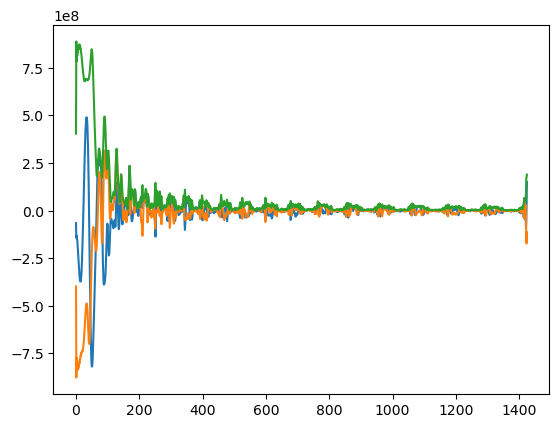

In [2]:
raw_path = "./TestData/BrukerPV360/Spiral2d1Intlv"

Spiral2d1Intlv = BrukerPV360Exp(raw_path, is_verbose=False)

FID = Spiral2d1Intlv.dataset['DATA']['rawdata'][0]


print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_NRepetitions']))
print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_SpiralNbOfInterleaves']))
print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_Matrix']))
print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_EncMatrix']))
print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_EncSteps2']))
print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_SpiralNbOfAcqPoints']))
print((Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_SpatResol']))
print(np.shape(FID))
plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.plot(np.abs(FID))
plt.show

(7126,)


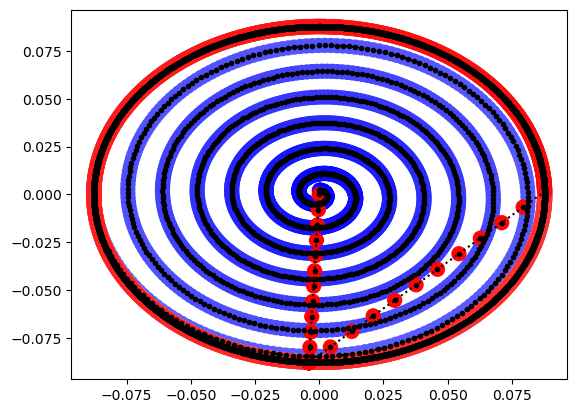

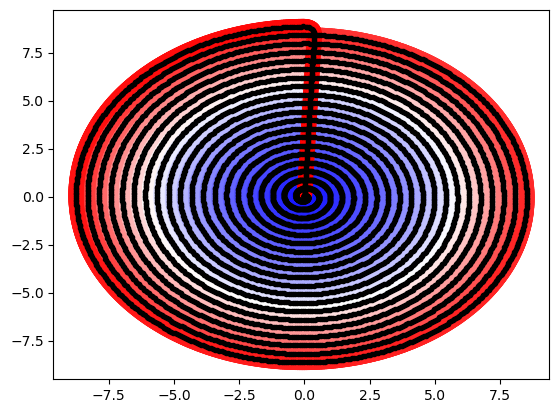

In [3]:
spiral_y = (Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_SpiralShape1'])
spiral_x = (Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_SpiralShape2'])

print(np.shape(spiral_x))

plt.figure()
plt.scatter(spiral_x, spiral_y, c=(range(len(spiral_x))), s=100, cmap='bwr')
plt.plot(spiral_x, spiral_y, c= "black", marker='.', linestyle=':')
plt.show()

traj_cal_x = np.cumsum(spiral_x)
traj_cal_y = np.cumsum(spiral_y)

plt.figure()
plt.scatter(traj_cal_x, traj_cal_y, c=(range(len(traj_cal_y))), s=100, cmap='bwr')
plt.plot(traj_cal_x, traj_cal_y, c= "black", marker='.', linestyle=':')
plt.scatter(traj_cal_x, traj_cal_y, c=(range(len(traj_cal_y))), s=100, cmap='bwr')
plt.show()


[-4.8701477e-06 -9.4501302e-05]


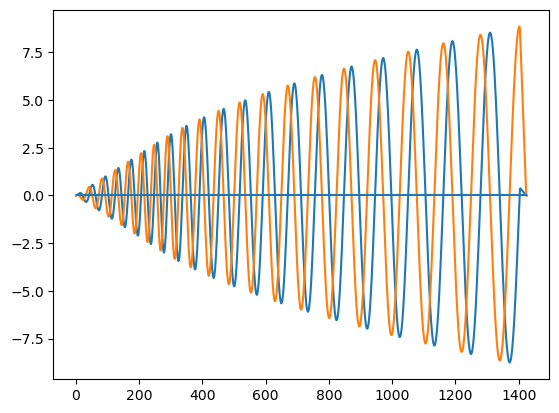

In [4]:
spiral_traj_cal = np.asarray(list(zip(traj_cal_x,traj_cal_y)))[::5]

print(spiral_traj_cal[-1])
plt.plot(spiral_traj_cal)
plt.hlines(y=0,xmin=0,xmax=len(spiral_traj_cal))

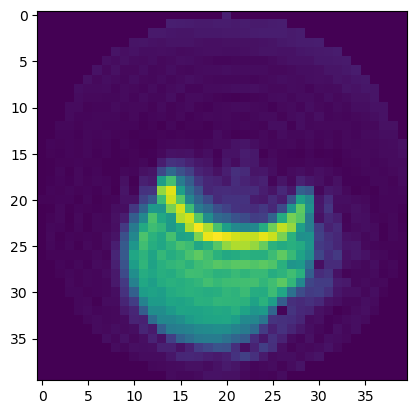

In [5]:
bruker_data = Spiral2d1Intlv.dataset['DATA']['2dseq']

img_shape = [int(x) for x in Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_Matrix']]

NR = Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_NRepetitions']

bruker_data = np.reshape(bruker_data, img_shape)
plt.figure()
plt.imshow(bruker_data, cmap=cm.viridis)
plt.show()


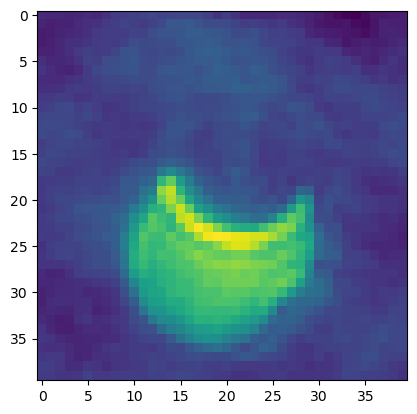

In [6]:
Nd = tuple(img_shape)  # image size
Kd = tuple([4*x for x in img_shape])  # k-space size
Jd = (6, 6)  # interpolation size

spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj_cal, Nd, Kd, Jd)

bruker_data = np.reshape(bruker_data, img_shape)
y_cal = spiralObj.forward(bruker_data)
recon = spiralObj.solve(y_cal, solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(recon.real, cmap=cm.viridis)
plt.show()


(1425,) (1426, 2)


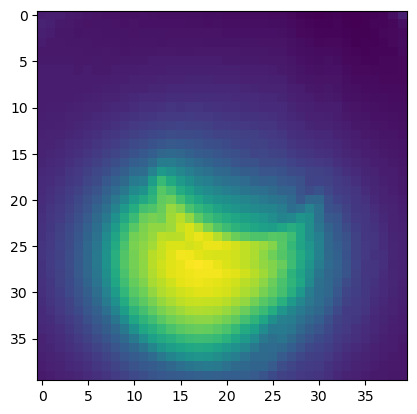

In [7]:
Nd = tuple(img_shape)  # image size
Kd = tuple([64*x for x in img_shape])  # k-space size
Jd = (6, 6)  # interpolation size


print(np.shape(FID), np.shape(spiral_traj_cal))
spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj_cal[1:]/np.pi, Nd, Kd, Jd)


recon = spiralObj.solve(np.roll(FID, 0), solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(np.abs(recon), cmap=cm.viridis)
plt.show()


(1425,) (1426, 2)


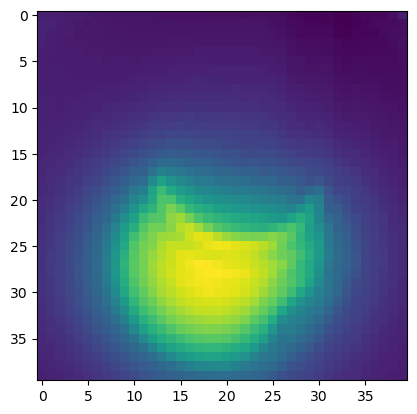

In [8]:
print(np.shape(FID), np.shape(spiral_traj_cal))
spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj_cal[:-1]/np.pi, Nd, Kd, Jd)


recon = spiralObj.solve(np.roll(FID, 0), solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(np.abs(recon), cmap=cm.viridis)
plt.show()

(1425,) (1426, 2)


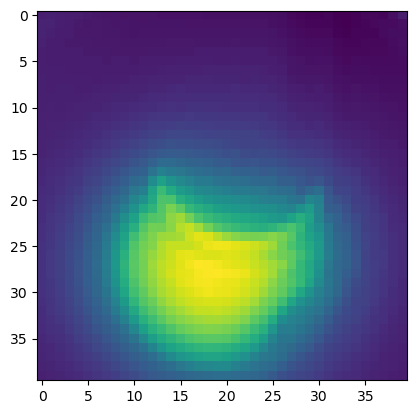

In [9]:
print(np.shape(FID), np.shape(spiral_traj_cal))
spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj_cal[1:]/np.pi, Nd, Kd, Jd)


recon = spiralObj.solve(np.roll(FID, -1), solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(np.abs(recon), cmap=cm.viridis)
plt.show()

1
4
[16. 16.]
[16. 16.]
[0.]
155
[3. 3.]
(620,)


<function matplotlib.pyplot.show(close=None, block=None)>

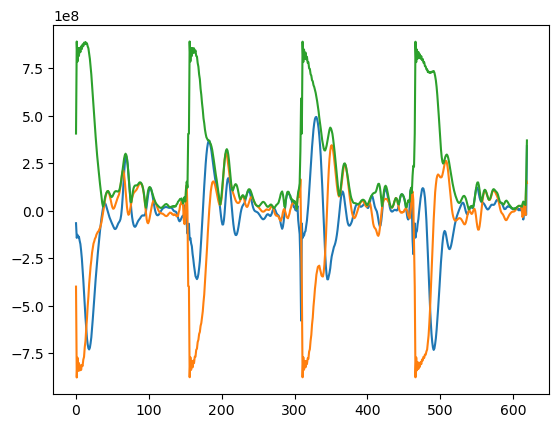

In [10]:
raw_path = "./TestData/BrukerPV360/Spiral2d4Intlv"

Spiral2d4Intlv = BrukerPV360Exp(raw_path, is_verbose=False)

FID = Spiral2d4Intlv.dataset['DATA']['rawdata'][0]


print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_NRepetitions']))
print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralNbOfInterleaves']))
print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_Matrix']))
print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_EncMatrix']))
print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_EncSteps2']))
print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralNbOfAcqPoints']))
print((Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpatResol']))
print(np.shape(FID))

plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.plot(np.abs(FID))
plt.show

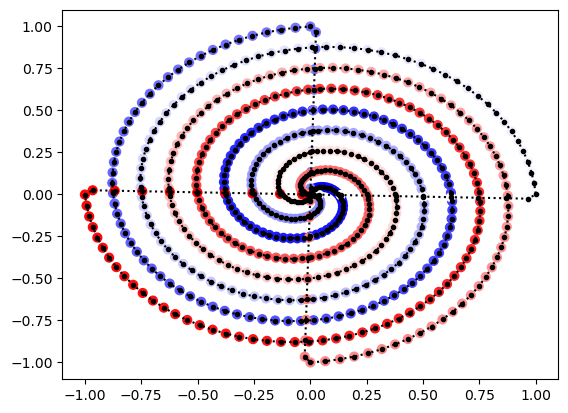

In [11]:
spiral_y = (Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralShape1'])
spiral_x = (Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralShape2'])

traj_cal_x = np.cumsum(spiral_x)[::5]
traj_cal_y = np.cumsum(spiral_y)[::5]

shift_cos = (Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralInterleavCos'])
shift_sin = (Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralInterleavSin'])
shift_angle = np.angle(shift_cos+1j*shift_sin)

traj_cal_seg = traj_cal_x + 1j*traj_cal_y
traj_cal = []
for angle in shift_angle:
    traj_cal.append(traj_cal_seg[:155] * np.exp(-angle*1j))

traj_cal = np.asarray(traj_cal).flatten()
traj_Kxy = normalize_array(traj_cal)

plt.figure()
plt.plot(traj_Kxy.real, traj_Kxy.imag, c= "black", marker='.', linestyle=':')
plt.scatter(traj_Kxy.real, traj_Kxy.imag, c=(range(len(traj_cal))), s=40, cmap='bwr')
plt.show()



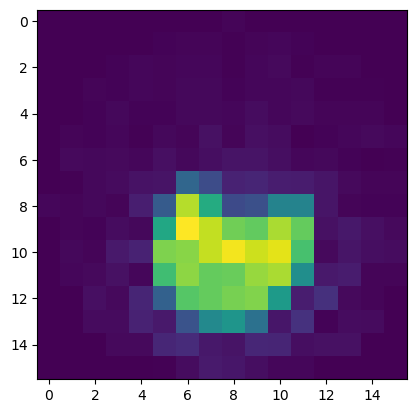

In [12]:
bruker_data = Spiral2d4Intlv.dataset['DATA']['2dseq']

img_shape = [int(x) for x in Spiral2d4Intlv.dataset['PARAM']['method'][0]['PVM_Matrix']]

NR = Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_NRepetitions']

bruker_data = np.reshape(bruker_data, img_shape)
plt.figure()
plt.imshow(bruker_data, cmap=cm.viridis)
plt.show()

(620,) (1426, 2)


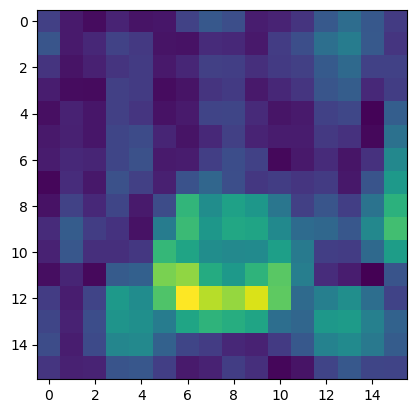

In [13]:
Nd = tuple(img_shape)  # image size
Kd = tuple([4*x for x in img_shape])  # k-space size
Jd = (6, 6)  # interpolation size

spiral_traj = np.asarray([[Kxy.real, Kxy.imag] for Kxy in traj_Kxy ])

print(np.shape(FID), np.shape(spiral_traj_cal))
spiralObj = pynufft.NUFFT()
spiralObj.plan(spiral_traj*np.pi, Nd, Kd, Jd)


recon = spiralObj.solve(np.roll(FID, 0), solver='bicgstab', maxiter=500)
plt.figure()
plt.imshow(np.abs(recon), cmap=cm.viridis)
plt.show()

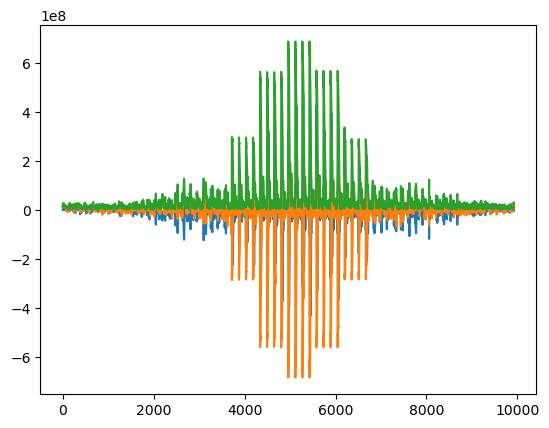

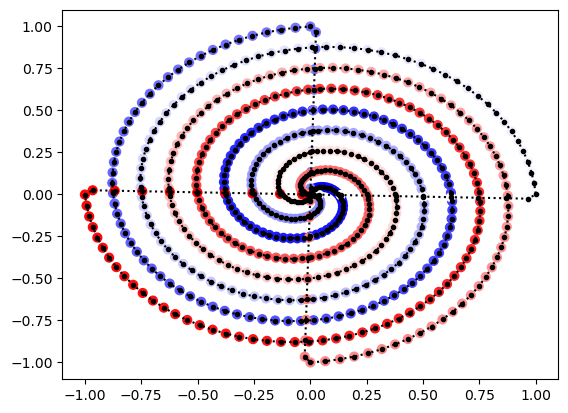

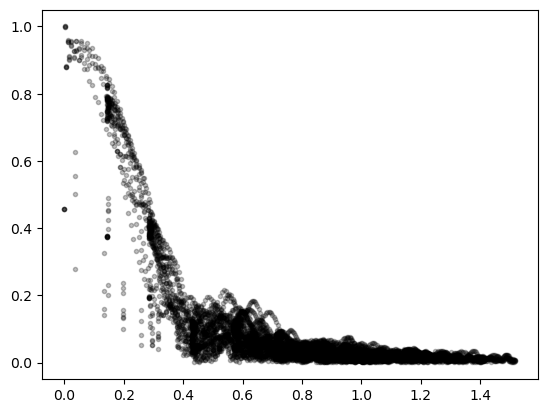

In [14]:
raw_path = "./TestData/BrukerPV360/Spiral3d4Intlv"

Spiral3d4Intlv = BrukerPV360Exp(raw_path, is_verbose=False)

FID = Spiral3d4Intlv.dataset['DATA']['rawdata'][0]

plt.plot(np.real(FID))
plt.plot(np.imag(FID))
plt.plot(np.abs(FID))
plt.show

spiral_y = (Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralShape1'])
spiral_x = (Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralShape2'])

traj_cal_x = np.cumsum(spiral_x)[::5]
traj_cal_y = np.cumsum(spiral_y)[::5]

shift_cos = (Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralInterleavCos'])
shift_sin = (Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralInterleavSin'])
shift_angle = np.angle(shift_cos+1j*shift_sin)

traj_cal_seg = traj_cal_x + 1j*traj_cal_y
traj_cal = []
for angle in shift_angle:
    traj_cal.append(traj_cal_seg[:155] * np.exp(-angle*1j))

traj_cal = np.asarray(traj_cal).flatten()
traj_Kxy = traj_cal / np.max(np.abs(traj_cal))

plt.figure()
plt.plot(traj_Kxy.real, traj_Kxy.imag, c= "black", marker='.', linestyle=':')
plt.scatter(traj_Kxy.real, traj_Kxy.imag, c=(range(len(traj_cal))), s=40, cmap='bwr')
plt.show()

traj_Kz = Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_EncSteps2']
traj_Kz = traj_Kz / np.max(traj_Kz)

traj_K3d = []
for kz in traj_Kz:
    for kxy in traj_Kxy:
        traj_K3d.append([kxy.real, kxy.imag, kz])
traj_K3d = np.asarray(traj_K3d)

traj_K3d_norm = np.linalg.norm(traj_K3d, ord=2, axis=1)
plt.figure()
plt.scatter(traj_K3d_norm,normalize_array(np.abs(FID)), c= "black", marker='.',alpha=.25)
plt.show()

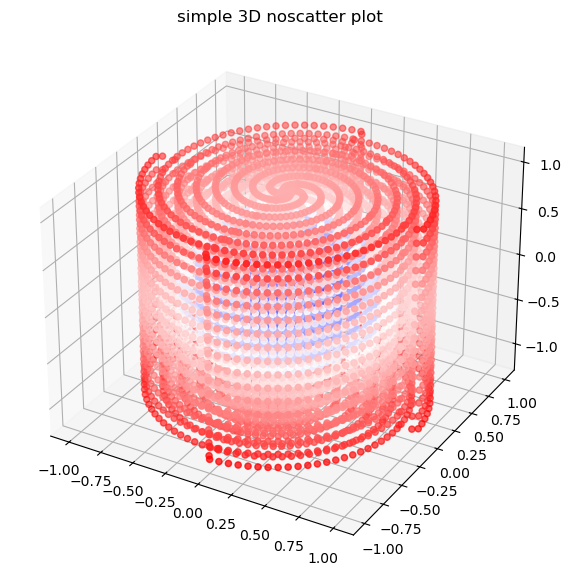

In [15]:
fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")

ax.scatter3D(traj_K3d[:,0], traj_K3d[:,1], traj_K3d[:,2], c = traj_K3d_norm, cmap='bwr')
plt.title("simple 3D noscatter plot")
 
# show plot
plt.show()

In [16]:
print((Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_NRepetitions']))
print((Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralNbOfInterleaves']))
print((Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_Matrix']))
print((Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_EncMatrix']))
print((Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_EncSteps2']))
print((Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_SpiralNbOfAcqPoints']))
print((Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_SpatResol']))



1
4
[16. 16. 16.]
[16. 16. 16.]
[-8. -7. -6. -5. -4. -3. -2. -1.  0.  1.  2.  3.  4.  5.  6.  7.]
155
[3. 3. 3.]


[16, 16, 16]


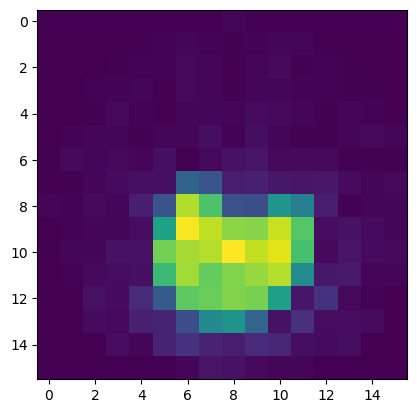

In [17]:
bruker_data = Spiral3d4Intlv.dataset['DATA']['2dseq']

img_shape = [int(x) for x in Spiral3d4Intlv.dataset['PARAM']['method'][0]['PVM_Matrix']]
print(img_shape)
NR = Spiral2d1Intlv.dataset['PARAM']['method'][0]['PVM_NRepetitions']

bruker_data = np.reshape(bruker_data, img_shape)
plt.figure()
plt.imshow(bruker_data[8], cmap=cm.viridis)
plt.show()

(9920,) (620,) (9920, 3)
(16, 16, 16) (64, 64, 64) (6, 6, 6)
8.112670660018921


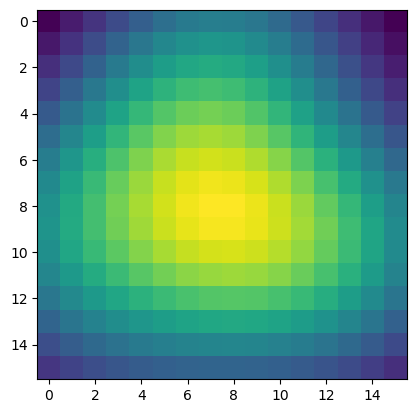

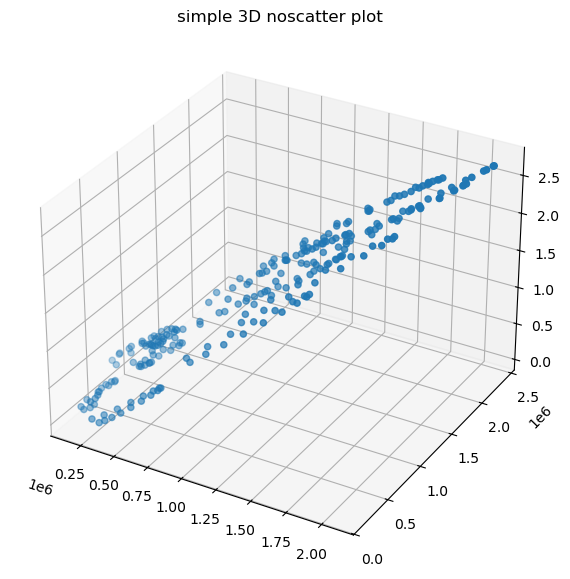

In [22]:
Nd = tuple(img_shape)  # image size
Kd = tuple([4*x for x in img_shape])  # k-space size
Jd = (6, 6, 6)  # interpolation size

print(np.shape(FID), np.shape(traj_Kxy), np.shape(traj_K3d))
print(Nd, Kd, Jd)

spiralStackObj = pynufft.NUFFT()
spiralStackObj.plan(traj_K3d*.3, Nd, Kd, Jd)

time1 = time.time()
recon = spiralStackObj.solve(FID, solver='cg', maxiter=500)
time2 = time.time()
print(time2-time1)

plt.figure()
plt.imshow(np.abs(recon)[0], cmap=cm.viridis)
plt.show()

fig = plt.figure(figsize = (10, 7))
ax = plt.axes(projection ="3d")

ax.scatter3D(np.abs(recon)[:,0], np.abs(recon)[:,1], np.abs(recon)[:,2])
plt.title("simple 3D noscatter plot")
 
# show plot
plt.show()

(9920,) (620,) (9920, 3)
(16, 16, 16) (64, 64, 64) (6, 6, 6)
No OpenCL device found. Check your pyopencl installation.
1.7085487842559814


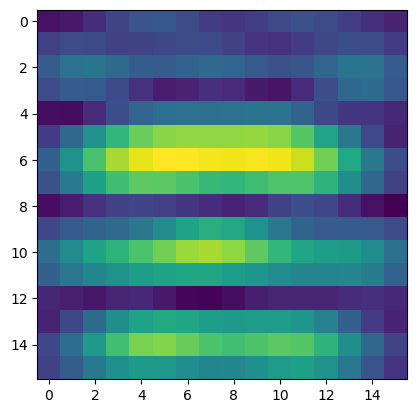

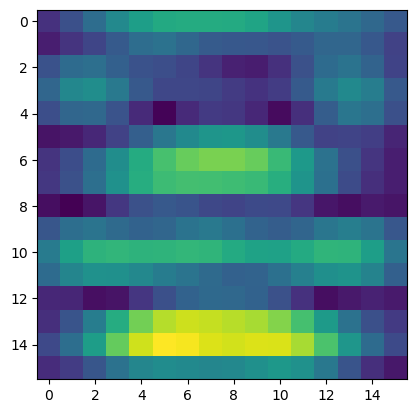

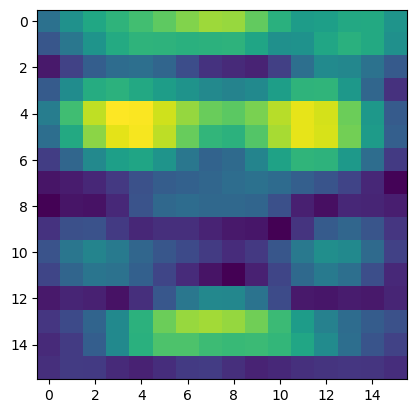

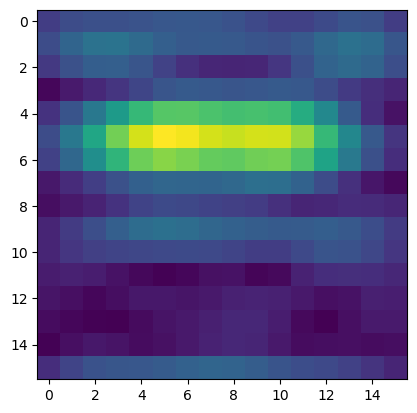

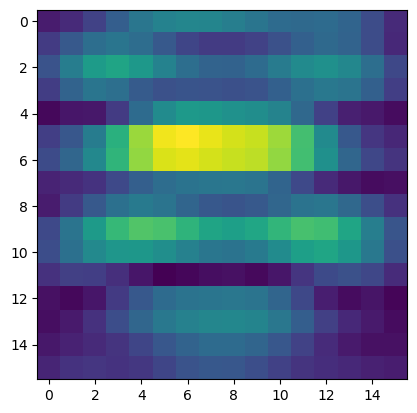

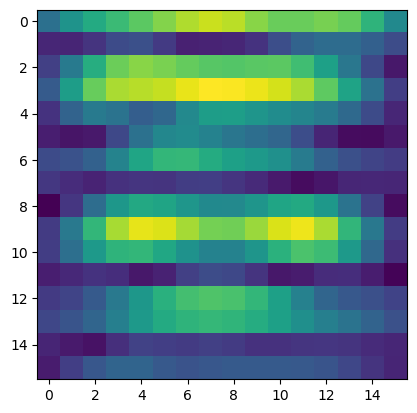

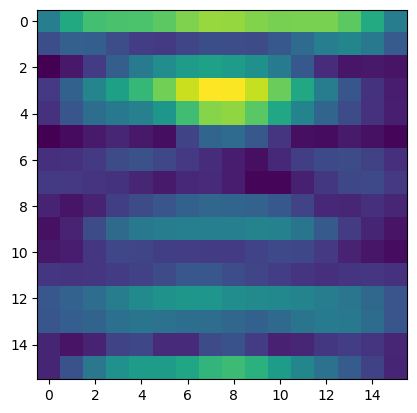

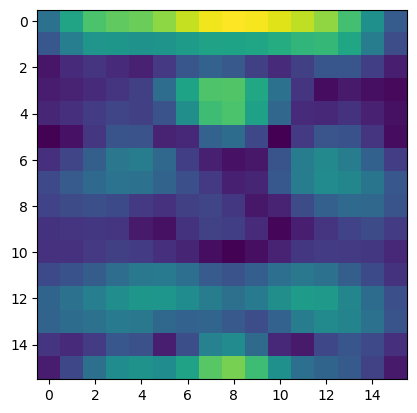

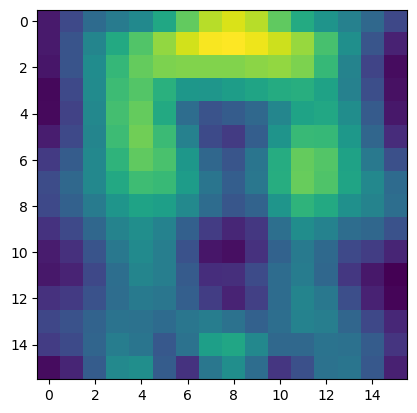

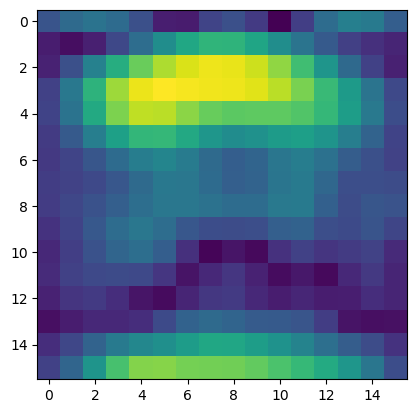

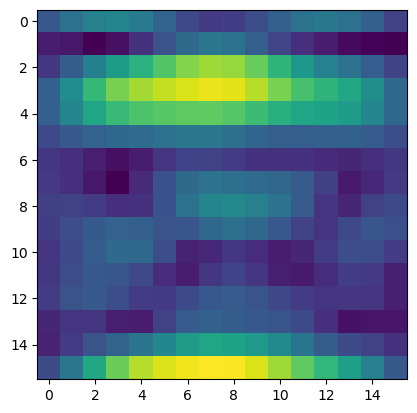

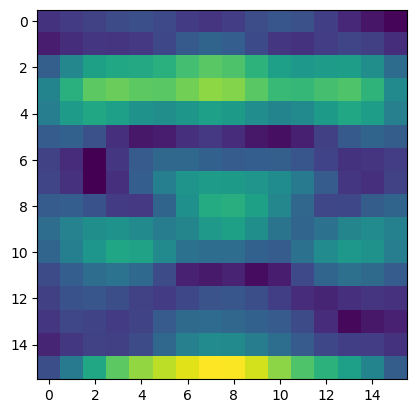

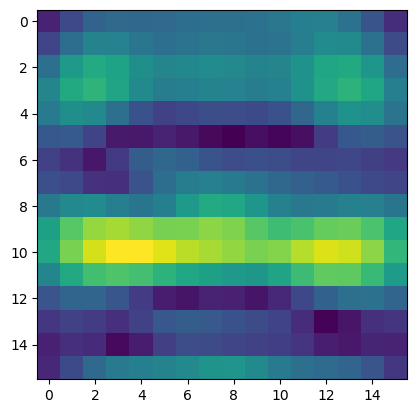

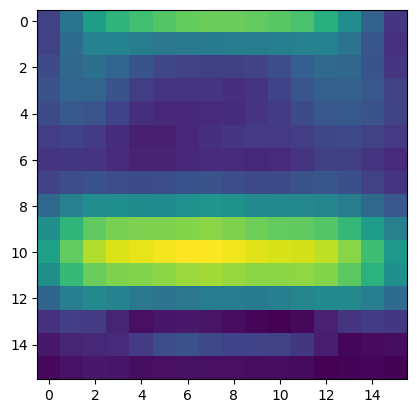

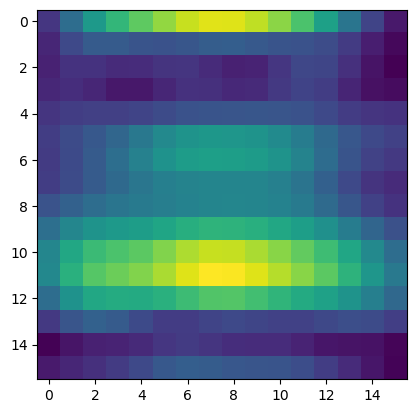

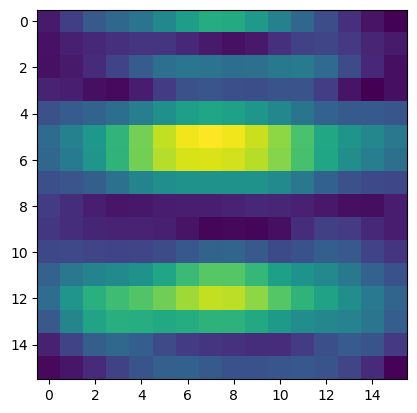

In [32]:
Nd = tuple(img_shape)  # image size
Kd = tuple([4*x for x in img_shape])  # k-space size
Jd = (6, 6, 6)  # interpolation size

print(np.shape(FID), np.shape(traj_Kxy), np.shape(traj_K3d))
print(Nd, Kd, Jd)

spiralStackObj = pynufft.NUFFT(pynufft.helper.device_list()[0])
spiralStackObj.plan(traj_K3d*1, Nd, Kd, Jd)

time1 = time.time()
recon = spiralStackObj.solve(FID, solver='cg', maxiter=500)
time2 = time.time()
print(time2-time1)



for i in range(16):
    plt.figure()
    plt.imshow(np.abs(recon)[i], cmap=cm.viridis)
    plt.show()

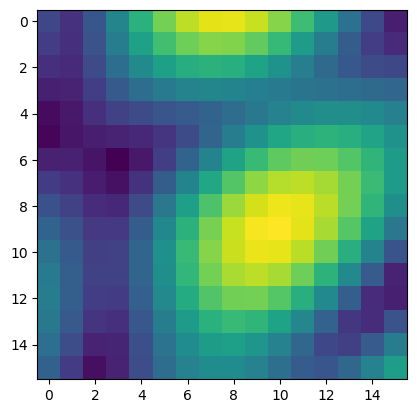

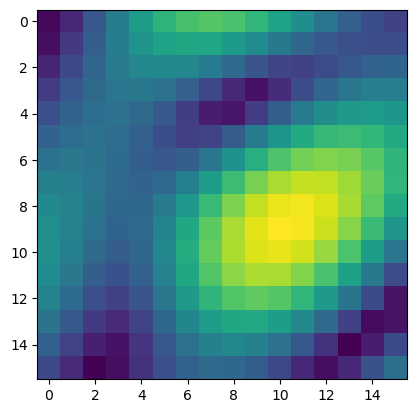

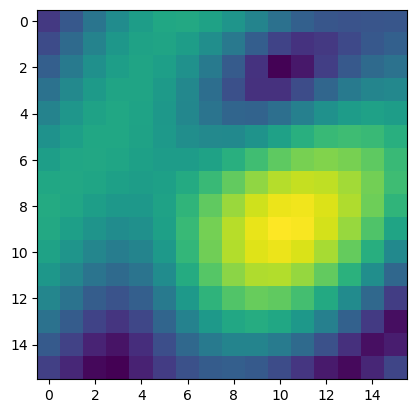

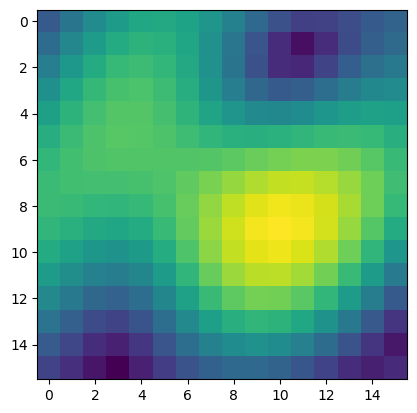

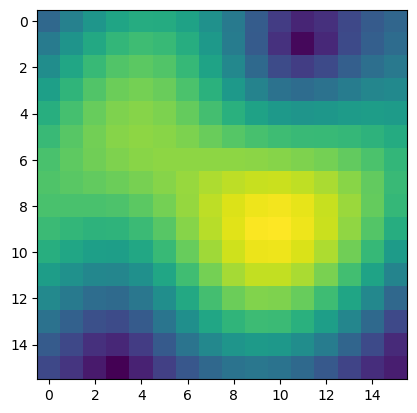

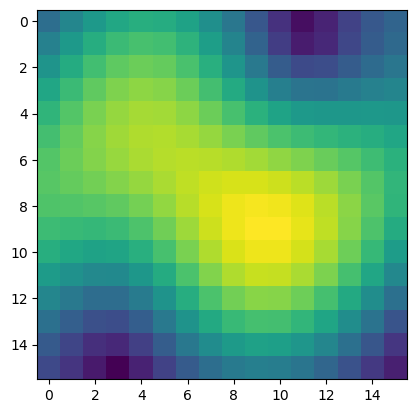

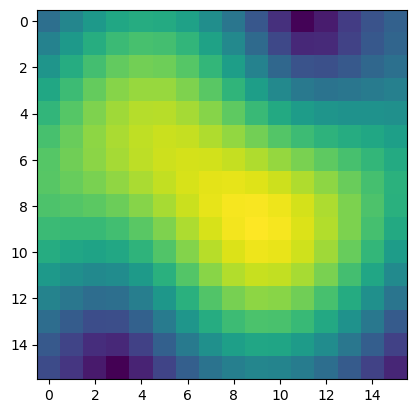

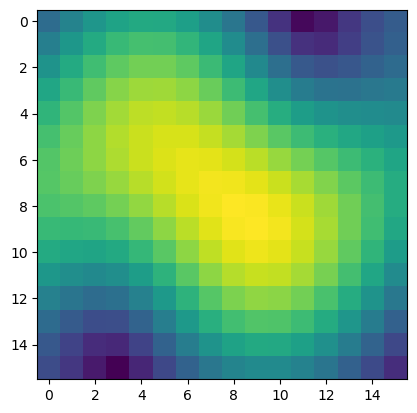

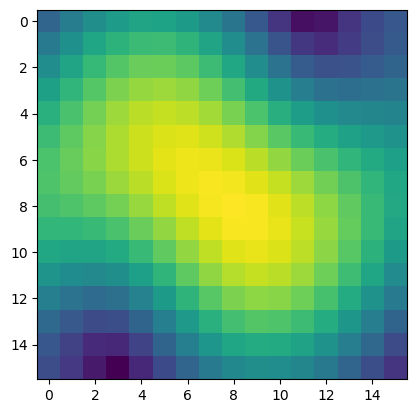

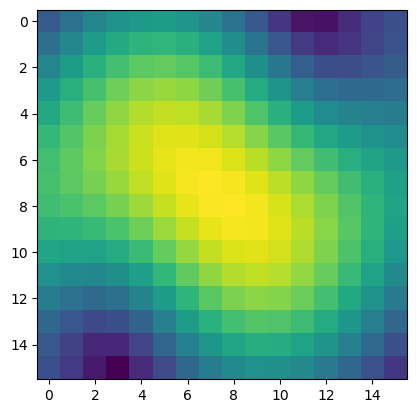

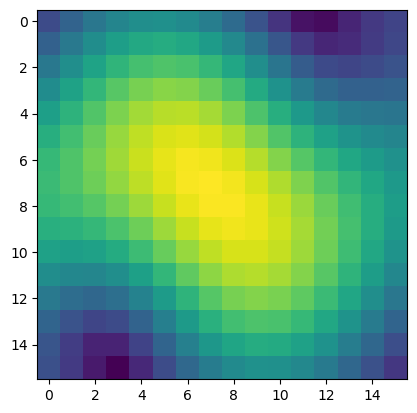

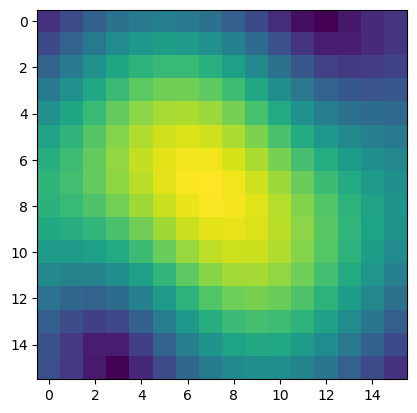

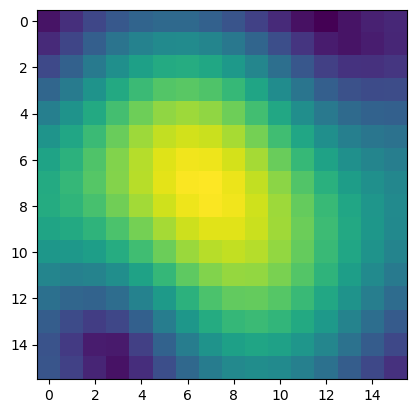

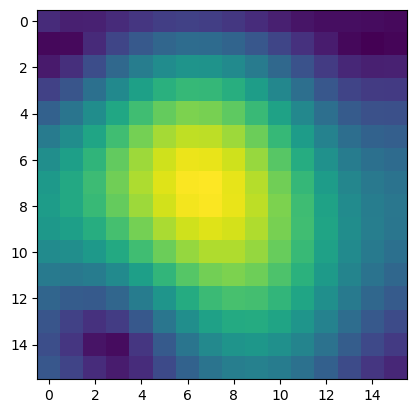

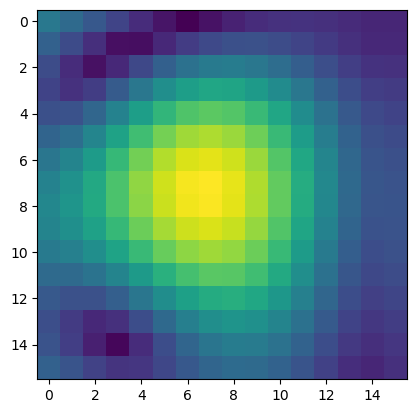

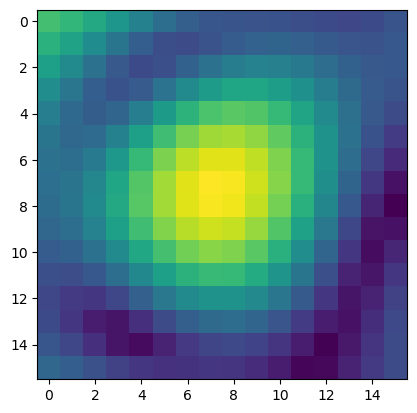